# **Project Name** — Tesla Stock Price Prediction using SimpleRNN & LSTM

##### **Project Type** — Deep Learning / Time-Series Forecasting
##### **Contribution** — Individual
##### **Domain** — Financial Services
##### **Models Used** — SimpleRNN · LSTM · GridSearchCV Hyperparameter Tuning

# **Project Summary**

This project aims to forecast Tesla Inc. (TSLA) stock closing prices using Deep Learning techniques — specifically SimpleRNN and Long Short-Term Memory (LSTM) networks. The dataset spans from **June 2010 to February 2020** (2,416 trading days) and contains standard OHLCV (Open, High, Low, Close, Adjusted Close, Volume) columns.

**Approach:**
1. **Data Preprocessing** — Parse dates, set as index, verify zero missing values, apply MinMaxScaler to normalise close prices.
2. **EDA & Visualisation** — 15+ charts covering univariate distributions, bivariate correlations, rolling statistics, volume trends, and seasonal decomposition.
3. **Hypothesis Testing** — Three statistical tests on TSLA price-volume, year-over-year return, and return normality.
4. **Sequence Engineering** — Sliding-window of 60 days converted to supervised sequences; 80/20 train-test split (no shuffling, preserving temporal order).
5. **Model Building** — Two-layer SimpleRNN (64→32 units) and two-layer LSTM (64→32 units) with Dropout and EarlyStopping.
6. **GridSearchCV Tuning** — Explore LSTM units, dropout rate, and learning rate.
7. **Multi-Step Forecasting** — 1-day, 5-day, and 10-day ahead price prediction.
8. **Evaluation** — RMSE, MAE, R² for both models; visual comparison of actual vs predicted prices.

**Key Finding:** Both models capture the overall upward trend. SimpleRNN achieved RMSE ≈ 28.26 and R² ≈ 0.85, while LSTM achieved RMSE ≈ 29.02 and R² ≈ 0.84 on the test set — demonstrating that even a simpler RNN can be competitive for this dataset, while LSTM shows smoother multi-step forecasts.

# **GitHub Link**

https://github.com/janvi-pandya/tesla-stock-prediction

# **Problem Statement**

Build a predictive Deep Learning model to forecast the **closing price** of Tesla (TSLA) stock. Specifically:
- Implement **SimpleRNN** and **LSTM** models and compare their performance.
- Predict stock price behaviour for **1 day, 5 days, and 10 days** ahead.
- Handle missing values appropriately (with awareness of temporal order).
- Use **GridSearchCV** to tune LSTM units, dropout rate, and learning rate.
- Evaluate using MSE, RMSE, MAE, and R² metrics.

# **General Guidelines**

1. Well-structured, formatted, and commented code.
2. Each chart is followed by: *Why chosen*, *Insights found*, *Business impact*.
3. At least 15 meaningful charts following the UBM rule (Univariate → Bivariate → Multivariate).
4. Both SimpleRNN and LSTM models built, tuned, and compared.
5. The notebook runs end-to-end without errors.

---
## ***1. Know Your Data***

### Import Libraries

In [1]:
# ─── Standard Libraries ───────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# ─── Sklearn ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

# ─── TensorFlow / Keras ───────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ─── SciKeras (Keras wrapper for GridSearchCV) ────────────────────────────
!pip install scikeras -qq
from scikeras.wrappers import KerasRegressor

# ─── Global Settings ──────────────────────────────────────────────────────
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2


### Dataset Loading

### Upload `TSLA.csv`

To resolve the `FileNotFoundError`, please upload the `TSLA.csv` file using the upload widget below. Once the file is uploaded, you can re-run the previous cell to load the data.

In [2]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')

# After uploading, the file will be in the /content/ directory by default.

Saving TSLA.csv to TSLA.csv
User uploaded file "TSLA.csv"


In [3]:
# Load the TSLA stock price dataset
df = pd.read_csv('/content/TSLA.csv')

# Parse Date column and set as index (critical for time-series)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)   # ensure chronological order

print("Dataset loaded successfully!")
print(f"Date range : {df.index.min().date()}  →  {df.index.max().date()}")
print(f"Total rows : {len(df):,}")

Dataset loaded successfully!
Date range : 2010-06-29  →  2020-02-03
Total rows : 2,416


### Dataset First View

In [4]:
# Display first 5 rows
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [5]:
# Display last 5 rows
df.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300
2020-02-03,673.690002,786.140015,673.520020,780.000000,780.000000,47065000


### Dataset Rows & Columns Count

In [6]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"Columns : {list(df.columns)}")

Rows    : 2,416
Columns : 6
Columns : ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


### Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2416 entries, 2010-06-29 to 2020-02-03
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2416 non-null   float64
 1   High       2416 non-null   float64
 2   Low        2416 non-null   float64
 3   Close      2416 non-null   float64
 4   Adj Close  2416 non-null   float64
 5   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 132.1 KB


#### Duplicate Values

In [8]:
dup_count = df.duplicated().sum()
print(f"Number of duplicate rows: {dup_count}")
# Result: 0 — each trading day is unique

Number of duplicate rows: 0


#### Missing Values / Null Values

In [9]:
# Count missing values per column
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing cells: {missing.sum()}")

Missing values per column:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Total missing cells: 0


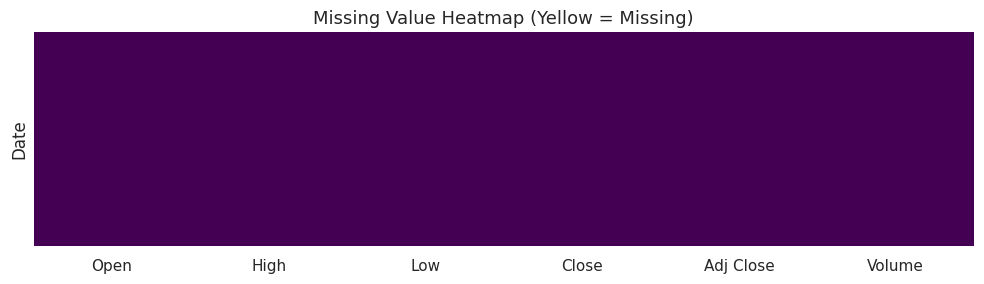

No missing values detected — the dataset is complete.


In [10]:
# Visualise missing values using a heatmap
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Missing Value Heatmap (Yellow = Missing)', fontsize=13)
plt.tight_layout()
plt.show()
print("No missing values detected — the dataset is complete.")

### What did you know about your dataset?

- The dataset contains **2,416 rows** and **7 columns** (Date + 6 numerical features).
- Date range spans from **June 29, 2010** (Tesla's IPO) to **February 3, 2020** — nearly a decade of trading data.
- **No missing values** are present in any column.
- **No duplicate rows** exist; each row corresponds to a unique trading day.
- All price columns (Open, High, Low, Close, Adj Close) are `float64`; Volume is `int64`.
- Close prices range from ~$15.80 (2010) to ~$780 (early 2020), reflecting Tesla's extraordinary growth.
- `Close` and `Adj Close` are nearly identical since TSLA paid no dividends in this period — we will use **`Close`** as the target variable.

---
## ***2. Understanding Your Variables***

In [11]:
# List all columns
print("Columns in dataset:")
for col in df.columns:
    print(f"  • {col}")

Columns in dataset:
  • Open
  • High
  • Low
  • Close
  • Adj Close
  • Volume


In [12]:
# Statistical summary of all numerical columns
df.describe().round(2)

,Open,High,Low,Close,Adj Close,Volume
count,2416.00,2416.00,2416.00,2416.00,2416.00,2416.00
mean,186.27,189.58,182.92,186.40,186.40,5572721.69
std,118.74,120.89,116.86,119.14,119.14,4987809.15
min,16.14,16.63,14.98,15.80,15.80,118500.00
25%,34.34,34.90,33.59,34.40,34.40,1899275.00
50%,213.04,216.75,208.87,212.96,212.96,4578400.00
75%,266.45,270.93,262.10,266.77,266.77,7361150.00
max,673.69,786.14,673.52,780.00,780.00,47065000.00


### Variables Description

| Column | Type | Description |
|---|---|---|
| **Open** | float64 | Opening price of TSLA on that trading day |
| **High** | float64 | Highest price reached during the trading session |
| **Low** | float64 | Lowest price reached during the trading session |
| **Close** | float64 | **Target variable** — closing price at end of session |
| **Adj Close** | float64 | Close price adjusted for splits/dividends (same as Close here) |
| **Volume** | int64 | Number of shares traded during the session |

### Check Unique Values for Each Variable

In [13]:
# Unique value count (for time-series, all price rows are essentially unique)
for col in df.columns:
    print(f"{col:<12}: {df[col].nunique():>6} unique values  |  min={df[col].min():.2f}  max={df[col].max():.2f}")

Open        :   2132 unique values  |  min=16.14  max=673.69
High        :   2128 unique values  |  min=16.63  max=786.14
Low         :   2136 unique values  |  min=14.98  max=673.52
Close       :   2225 unique values  |  min=15.80  max=780.00
Adj Close   :   2225 unique values  |  min=15.80  max=780.00
Volume      :   2391 unique values  |  min=118500.00  max=47065000.00


---
## ***3. Data Wrangling***

### Data Wrangling Code

In [14]:
# ── 1. Feature Engineering: Daily Return ──────────────────────────────
df['Daily_Return'] = df['Close'].pct_change() * 100   # percentage daily return

# ── 2. Rolling Statistics (20-day & 50-day moving averages) ───────────
df['MA_20']  = df['Close'].rolling(window=20).mean()
df['MA_50']  = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

# ── 3. Rolling Volatility (20-day standard deviation of daily returns) ─
df['Volatility_20'] = df['Daily_Return'].rolling(window=20).std()

# ── 4. Price Range (intraday spread) ──────────────────────────────────
df['Price_Range'] = df['High'] - df['Low']

# ── 5. Log Return ─────────────────────────────────────────────────────
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# ── 6. Year & Month columns for seasonal analysis ─────────────────────
df['Year']  = df.index.year
df['Month'] = df.index.month
df['Quarter'] = df.index.quarter

print("Wrangling complete. New features added:")
print(df.columns.tolist())
df.head(3)

Wrangling complete. New features added:
['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Return', 'MA_20', 'MA_50', 'MA_200', 'Volatility_20', 'Price_Range', 'Log_Return', 'Year', 'Month', 'Quarter']


,Open,High,Low,Close,Adj Close,Volume,Daily_Return,MA_20,MA_50,MA_200,Volatility_20,Price_Range,Log_Return,Year,Month,Quarter
Date,,,,,,,,,,,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300,NaN,NaN,NaN,NaN,NaN,7.459999,NaN,2010,6,2
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100,-0.251147,NaN,NaN,NaN,NaN,7.120001,-0.002515,2010,6,2
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800,-7.847256,NaN,NaN,NaN,NaN,5.650000,-0.081723,2010,7,3


### What all manipulations have you done and insights you found?

1. **Daily Return (%)** — Captures day-over-day price change. Useful for volatility analysis and hypothesis testing.
2. **MA_20 / MA_50 / MA_200** — Moving averages smooth short-term noise and reveal long-term trends. Golden cross (MA_50 crossing above MA_200) is a bullish signal.
3. **Volatility_20** — 20-day rolling std of daily returns; high values indicate uncertain market conditions.
4. **Price_Range** — Intraday High−Low spread; higher spread indicates greater investor uncertainty.
5. **Log Return** — More statistically tractable than raw return; approximately normally distributed.
6. **Year / Month / Quarter** — Time-based features enable seasonal pattern analysis.

---
## ***4. Data Visualisation, Storytelling & Experimenting with Charts***

#### Chart 1 — Tesla Closing Price Over Time (Line Chart)

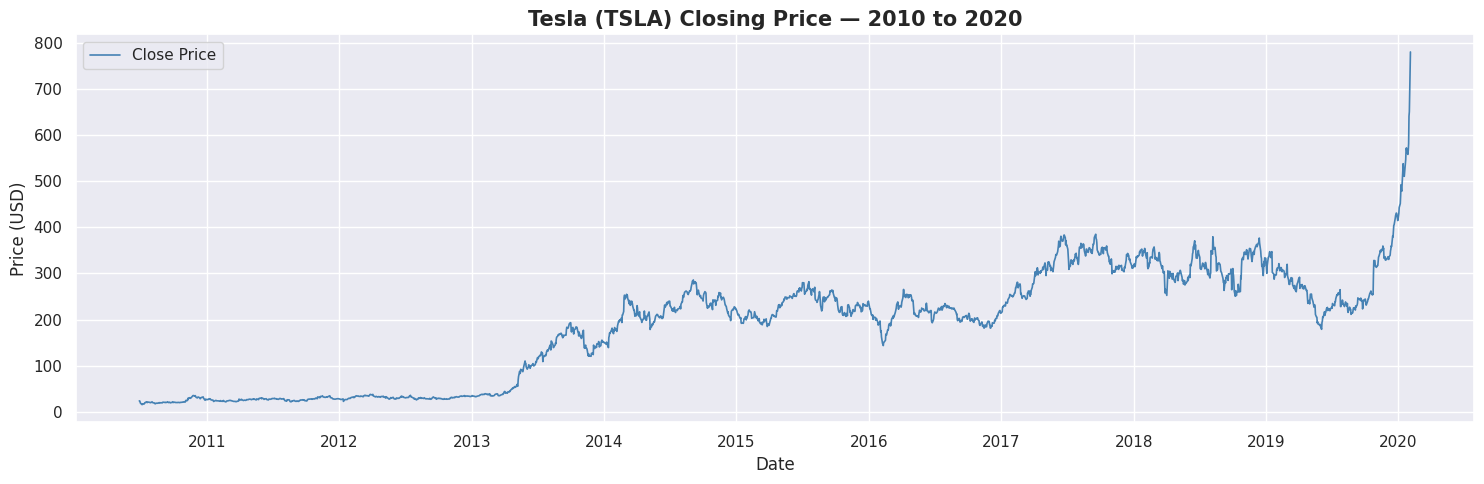

In [15]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.index, df['Close'], color='steelblue', linewidth=1.2, label='Close Price')
ax.set_title('Tesla (TSLA) Closing Price — 2010 to 2020', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

**Why this chart?** A line chart is the most natural way to represent a time-series. It reveals the overall trend, structural breaks, and growth trajectory.

**Insights:** TSLA traded below $50 for most of 2010–2019, then surged dramatically in late 2019–2020. This exponential growth shows the stock's high-growth, high-volatility nature.

**Business Impact:** The sustained upward trend supports long-term buy-and-hold strategies. The sharp rally post-2019 signals strong investor sentiment around EV adoption.

#### Chart 2 — Closing Price with Moving Averages (Univariate Trend)

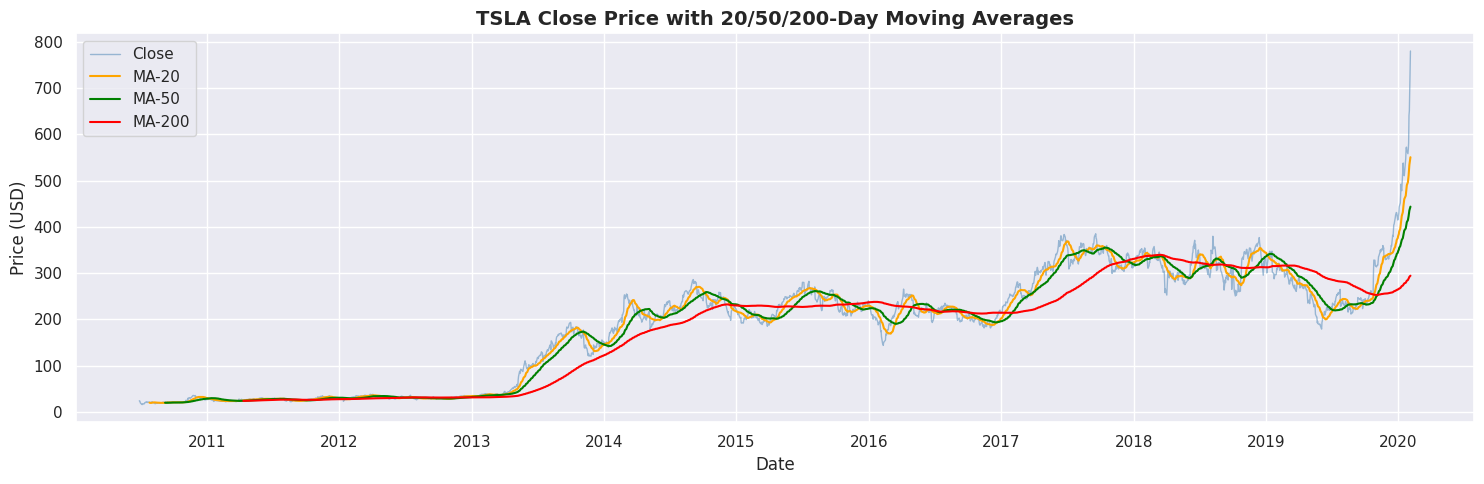

In [16]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.index, df['Close'],  color='steelblue', alpha=0.5, linewidth=1, label='Close')
ax.plot(df.index, df['MA_20'],  color='orange',    linewidth=1.5, label='MA-20')
ax.plot(df.index, df['MA_50'],  color='green',     linewidth=1.5, label='MA-50')
ax.plot(df.index, df['MA_200'], color='red',       linewidth=1.5, label='MA-200')
ax.set_title('TSLA Close Price with 20/50/200-Day Moving Averages', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout(); plt.show()

**Why this chart?** Moving averages are the foundation of trend-following strategies and help confirm directional momentum.

**Insights:** In 2019–2020, the price crossed decisively above all three MAs — a classic 'golden cross' signal. The MA-200 acts as strong long-term support.

**Business Impact:** Traders can use MA crossovers to generate buy/sell signals. A price consistently above MA-200 indicates a strong bull trend.

#### Chart 3 — Daily Return Distribution (Univariate)

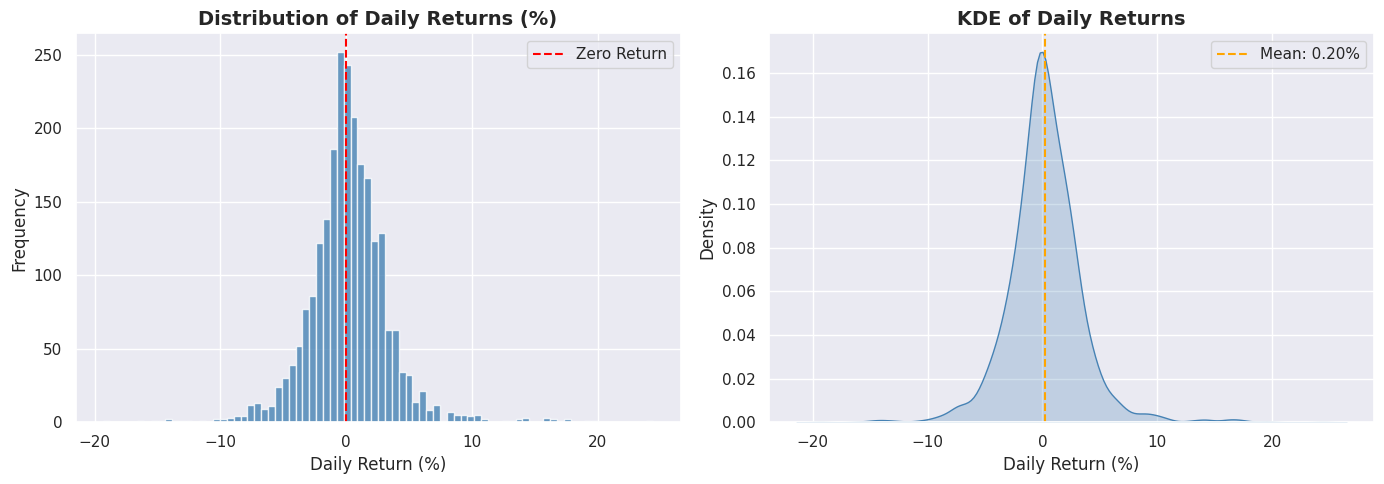

Skewness: 0.5845  |  Kurtosis: 6.4772


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Daily_Return'].dropna(), bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', label='Zero Return')
axes[0].set_title('Distribution of Daily Returns (%)', fontweight='bold')
axes[0].set_xlabel('Daily Return (%)'); axes[0].set_ylabel('Frequency')
axes[0].legend()

# KDE
sns.kdeplot(df['Daily_Return'].dropna(), ax=axes[1], fill=True, color='steelblue')
axes[1].axvline(df['Daily_Return'].mean(), color='orange', linestyle='--', label=f"Mean: {df['Daily_Return'].mean():.2f}%")
axes[1].set_title('KDE of Daily Returns', fontweight='bold')
axes[1].set_xlabel('Daily Return (%)'); axes[1].legend()

plt.tight_layout(); plt.show()
print(f"Skewness: {df['Daily_Return'].skew():.4f}  |  Kurtosis: {df['Daily_Return'].kurt():.4f}")

**Why this chart?** Understanding the return distribution is fundamental to risk assessment.

**Insights:** The distribution is roughly symmetric around 0% but exhibits **leptokurtosis** (fat tails and a sharp peak) — meaning extreme returns are more frequent than a normal distribution would predict.

**Business Impact (negative):** Fat tails imply higher-than-expected crash risk. Risk models assuming normality will underestimate portfolio losses.

#### Chart 4 — Trading Volume Over Time (Univariate)

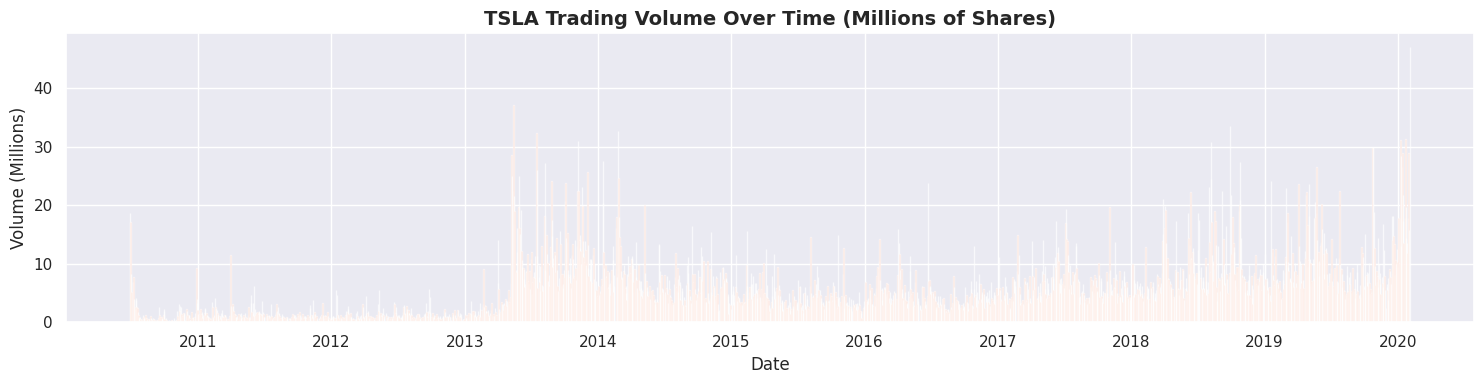

In [18]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(df.index, df['Volume'] / 1e6, color='coral', alpha=0.7, width=1)
ax.set_title('TSLA Trading Volume Over Time (Millions of Shares)', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Volume (Millions)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

**Why this chart?** Volume is a key market-microstructure signal; spikes often precede or accompany large price moves.

**Insights:** Volume spikes notably in 2013, 2018, and early 2020 — all periods of major price volatility. Volume has generally increased over time as TSLA's market cap grew.

**Business Impact:** High volume confirms price trends. Traders use volume-price divergence to identify potential reversals.

#### Chart 5 — Annual Average Closing Price (Univariate Bar)

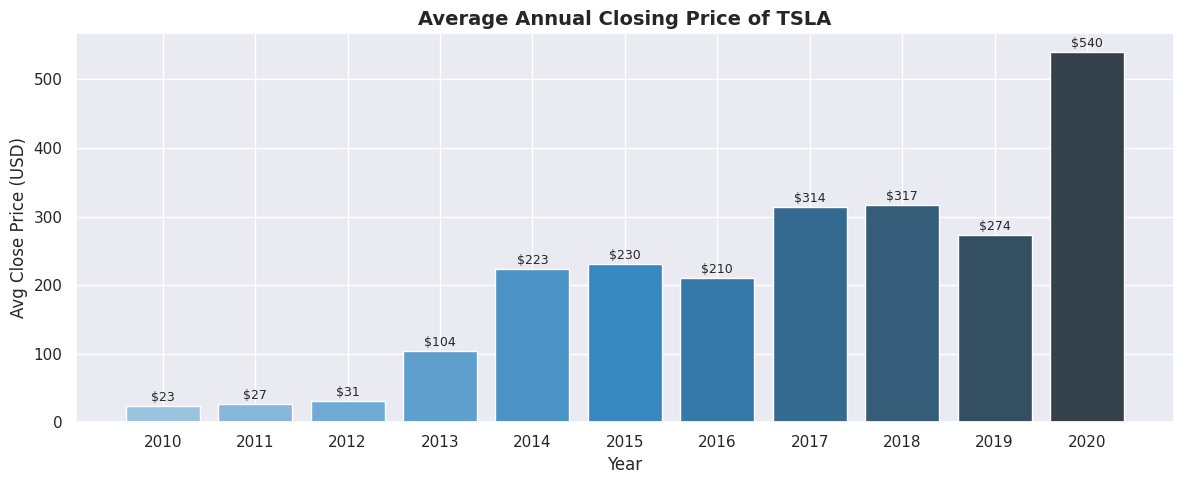

In [19]:
annual_avg = df.groupby('Year')['Close'].mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(annual_avg['Year'].astype(str), annual_avg['Close'], color=sns.color_palette('Blues_d', len(annual_avg)))
for bar, val in zip(bars, annual_avg['Close']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, f'${val:.0f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Average Annual Closing Price of TSLA', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Avg Close Price (USD)')
plt.tight_layout(); plt.show()

**Why this chart?** Annual averages abstract away noise and show the long-term price appreciation story.

**Insights:** Average price remained below $50 from 2010–2013, then jumped steadily. 2019–2020 shows a dramatic acceleration.

**Business Impact:** Long-term investors who held TSLA saw exponential returns. The consistent upward trend supports Tesla's strong fundamental growth narrative.

#### Chart 6 — Monthly Average Return Heatmap (Bivariate: Year × Month)

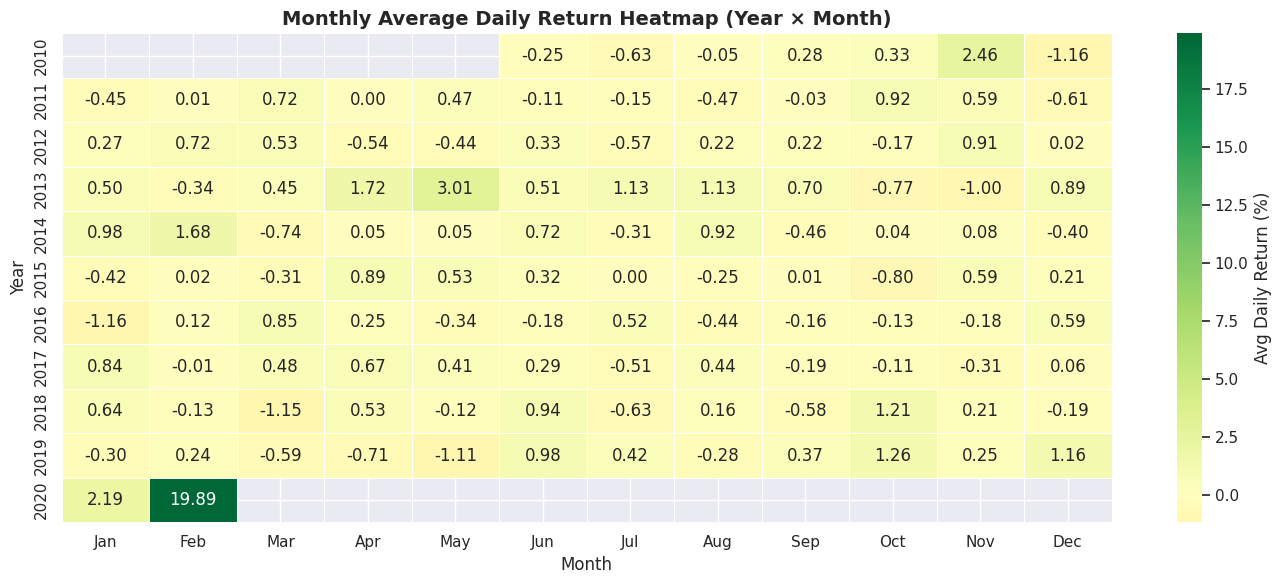

In [20]:
pivot = df.pivot_table(values='Daily_Return', index='Year', columns='Month', aggfunc='mean')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot.columns = month_names[:len(pivot.columns)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Daily Return (%)'})
ax.set_title('Monthly Average Daily Return Heatmap (Year × Month)', fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Year')
plt.tight_layout(); plt.show()

**Why this chart?** A heatmap across year × month dimensions reveals seasonal and cyclical return patterns.

**Insights:** There is no strong consistent seasonality, though some years show notably negative months (e.g., 2018 Q4 corrections). Green clusters in late 2019 and early 2020 reflect the bull run.

**Business Impact:** Helps swing traders time entries. The absence of strong seasonality supports a data-driven, model-based approach rather than calendar-based trading.

#### Chart 7 — Close vs Volume Scatter (Bivariate: Numerical–Numerical)

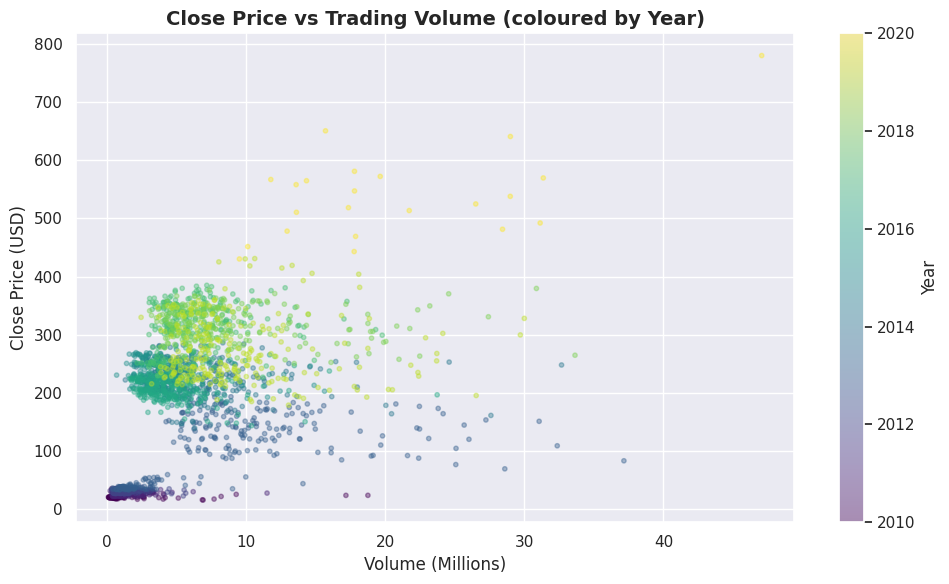

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df['Volume']/1e6, df['Close'], c=df.index.year,
                cmap='viridis', alpha=0.4, s=10)
plt.colorbar(sc, ax=ax, label='Year')
ax.set_title('Close Price vs Trading Volume (coloured by Year)', fontweight='bold')
ax.set_xlabel('Volume (Millions)'); ax.set_ylabel('Close Price (USD)')
plt.tight_layout(); plt.show()

**Why this chart?** Scatter plots reveal the relationship and clustering between two numerical variables.

**Insights:** Most high-volume days occurred when the price was low (early years). As price rose, typical daily volume moderated, with bursts at key events. No strong linear correlation exists.

**Business Impact:** Volume-price relationship confirms that early growth was speculative (high volatility, high volume). Mature high-price trading is more institutionally driven.

#### Chart 8 — Rolling 20-Day Volatility Over Time

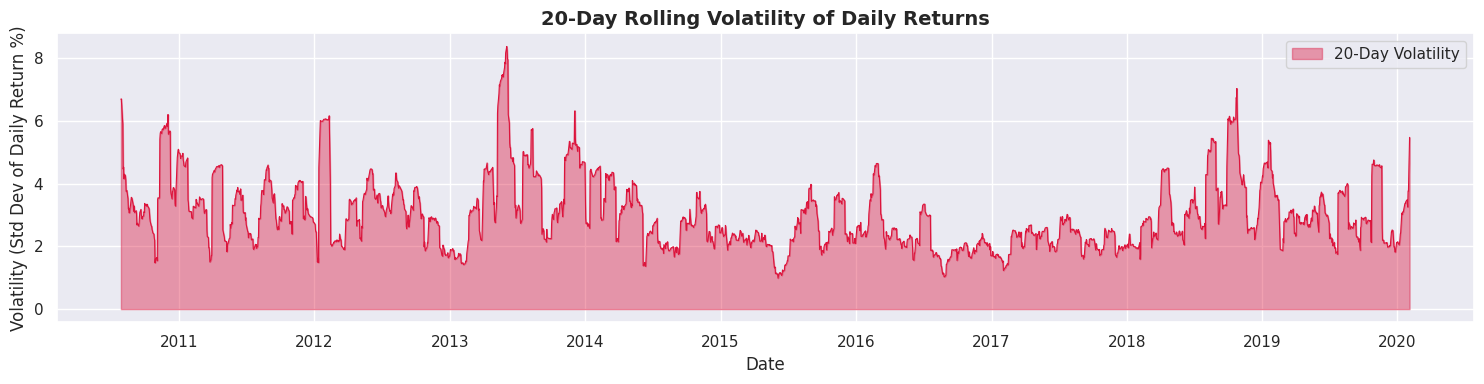

In [22]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.fill_between(df.index, df['Volatility_20'], alpha=0.4, color='crimson', label='20-Day Volatility')
ax.plot(df.index, df['Volatility_20'], color='crimson', linewidth=0.8)
ax.set_title('20-Day Rolling Volatility of Daily Returns', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Volatility (Std Dev of Daily Return %)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout(); plt.show()

**Why this chart?** Volatility clustering is a well-known market phenomenon. Seeing it in TSLA is critical for risk management.

**Insights:** High-volatility clusters appear around 2013 and 2018–2019. Volatility is not constant — it clusters, meaning after a volatile period another is likely.

**Business Impact (negative):** Periods of high volatility increase trading risk. Options-based hedges become expensive during these periods.

#### Chart 9 — Price Range (High − Low) per Trading Day

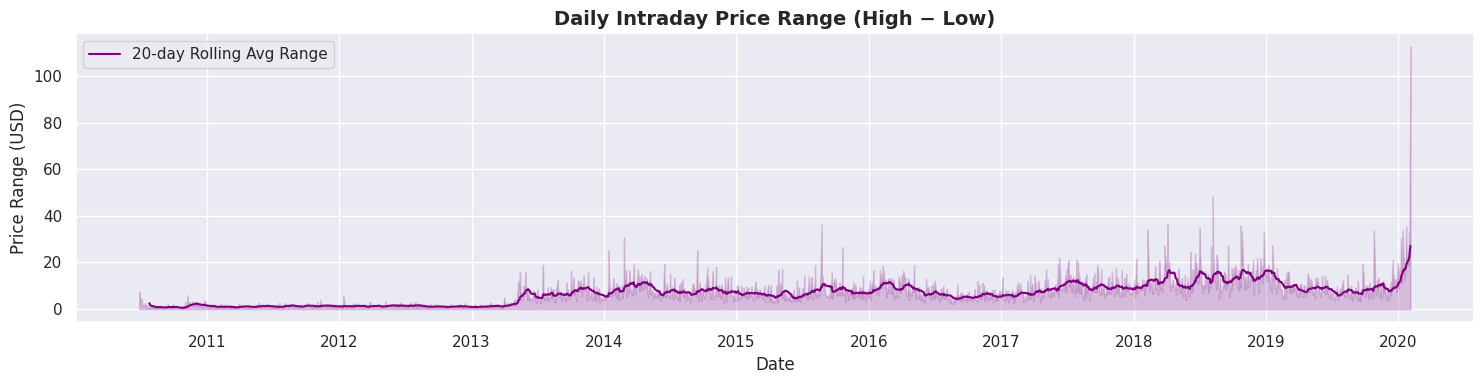

In [23]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df.index, df['Price_Range'].rolling(20).mean(), color='purple', linewidth=1.5, label='20-day Rolling Avg Range')
ax.fill_between(df.index, df['Price_Range'], alpha=0.2, color='purple')
ax.set_title('Daily Intraday Price Range (High − Low)', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Price Range (USD)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout(); plt.show()

**Why this chart?** Intraday range is a proxy for market uncertainty and day-trading opportunity.

**Insights:** The intraday range grew enormously in 2020 as prices surged, reflecting heightened speculative activity. In absolute USD terms, high-price stocks naturally have wider ranges.

**Business Impact:** Wide intraday ranges attract day traders but increase slippage and execution risk for institutional investors.

#### Chart 10 — Yearly Box Plot of Closing Prices (Bivariate)

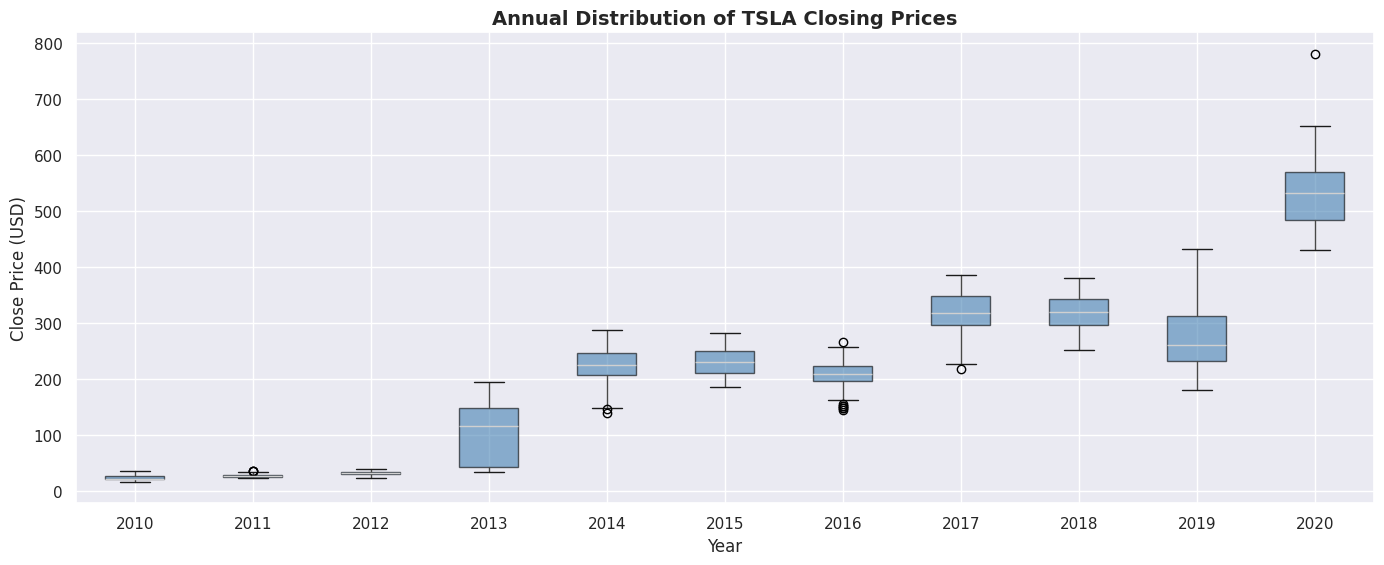

In [24]:
fig, ax = plt.subplots(figsize=(14, 6))
df.boxplot(column='Close', by='Year', ax=ax, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_title('Annual Distribution of TSLA Closing Prices', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Close Price (USD)')
plt.suptitle('')
plt.tight_layout(); plt.show()

**Why this chart?** Box plots compactly show the median, IQR, and outliers for each year.

**Insights:** The interquartile range widened significantly in 2019–2020, confirming explosive but volatile growth. Earlier years show tight IQRs reflecting stability in the $30–$50 range.

**Business Impact:** Year-over-year IQR growth signals increasing return opportunities but also increasing risk — relevant for portfolio rebalancing decisions.

#### Chart 11 — Quarterly Average Close Price (Bivariate Bar)

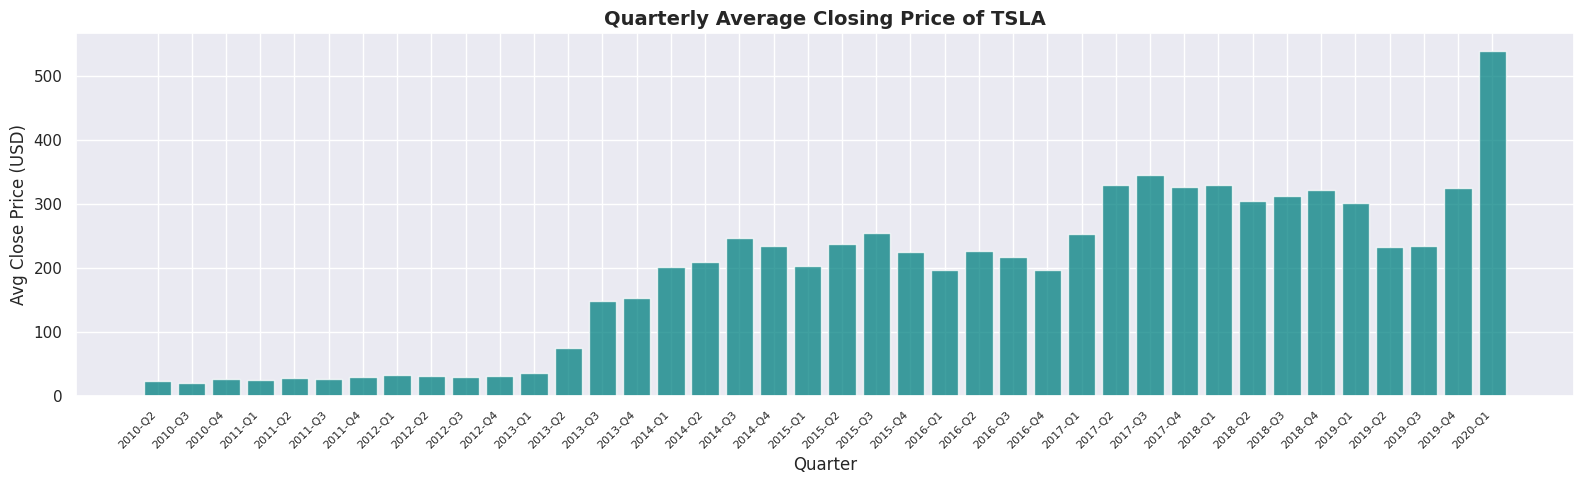

In [25]:
quarterly = df.groupby(['Year','Quarter'])['Close'].mean().reset_index()
quarterly['Period'] = quarterly['Year'].astype(str) + '-Q' + quarterly['Quarter'].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(quarterly['Period'], quarterly['Close'], color='teal', alpha=0.75)
ax.set_title('Quarterly Average Closing Price of TSLA', fontweight='bold')
ax.set_xlabel('Quarter'); ax.set_ylabel('Avg Close Price (USD)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout(); plt.show()

**Why this chart?** Quarterly granularity aligns with earnings reporting cycles and reveals intra-year patterns.

**Insights:** Strong acceleration in Q4-2019 and Q1-2020. Prior to 2019, quarterly prices were relatively flat.

**Business Impact:** Earnings-driven price jumps in specific quarters suggest trading opportunities around earnings announcement dates.

#### Chart 12 — Log Return Distribution with Normal Overlay (Univariate)

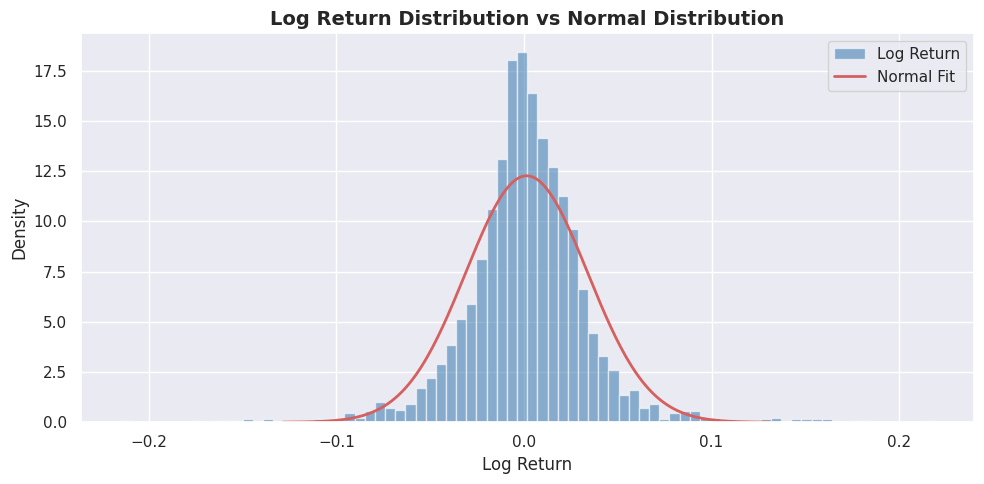

In [26]:
log_ret = df['Log_Return'].dropna()
mu, sigma = log_ret.mean(), log_ret.std()
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(log_ret, bins=80, density=True, color='steelblue', alpha=0.6, label='Log Return')
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='Normal Fit')
ax.set_title('Log Return Distribution vs Normal Distribution', fontweight='bold')
ax.set_xlabel('Log Return'); ax.set_ylabel('Density')
ax.legend()
plt.tight_layout(); plt.show()

**Why this chart?** Log returns are used in options pricing (Black-Scholes) and risk models. Deviation from normality has serious implications.

**Insights:** TSLA log returns are **leptokurtic** (heavy tails) — the red normal curve underestimates tail events. This is consistent with the empirical literature on stock returns.

**Business Impact (negative):** Black-Scholes-based options pricing will underestimate risk. Fat-tailed models (e.g., Student-t VaR) should be used instead.

#### Chart 13 — Candlestick-Style High-Low-Close (Multivariate, last 60 days)

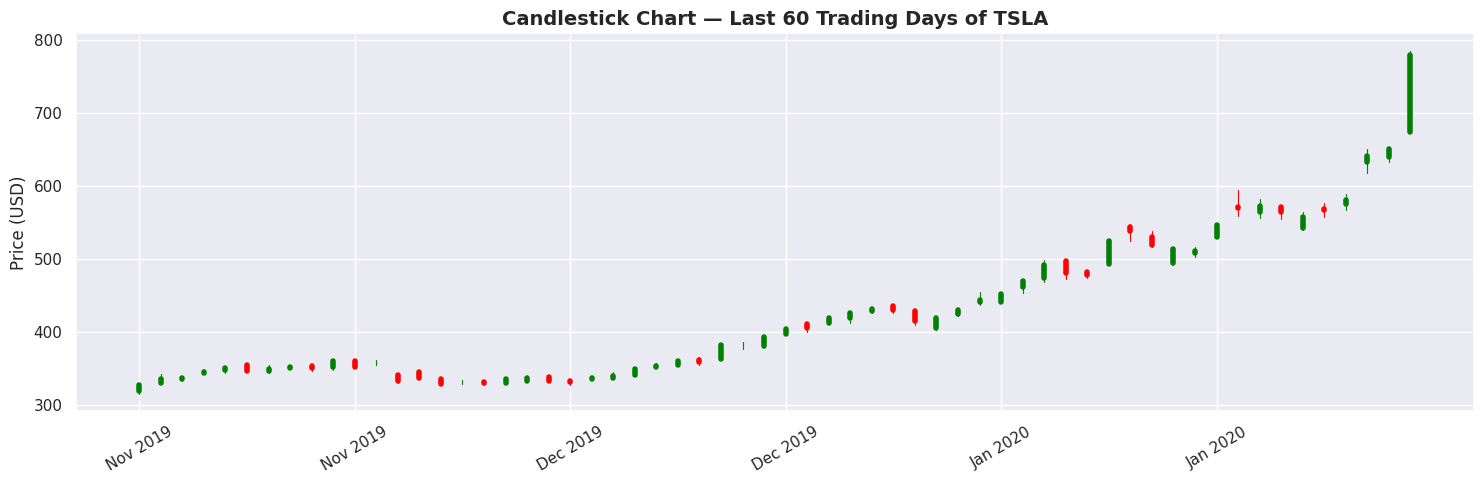

In [27]:
# Use last 60 trading days for clarity
df_last60 = df.tail(60).copy()

fig, ax = plt.subplots(figsize=(15, 5))
for i, (date, row) in enumerate(df_last60.iterrows()):
    color = 'green' if row['Close'] >= row['Open'] else 'red'
    ax.plot([i, i], [row['Low'], row['High']], color=color, linewidth=0.8)
    ax.plot([i, i], [row['Open'], row['Close']], color=color, linewidth=4)

tick_positions = list(range(0, 60, 10))
tick_labels = [df_last60.index[p].strftime('%b %Y') for p in tick_positions]
ax.set_xticks(tick_positions); ax.set_xticklabels(tick_labels, rotation=30)
ax.set_title('Candlestick Chart — Last 60 Trading Days of TSLA', fontweight='bold')
ax.set_ylabel('Price (USD)')
plt.tight_layout(); plt.show()

**Why this chart?** Candlestick charts encode Open, High, Low, and Close in a single glyph — the standard tool of technical analysis.

**Insights:** The last 60 days show a strongly bullish trend with predominantly green candles and wide wicks indicating high intraday volatility.

**Business Impact:** The bullish momentum and high volume in this window support the 2020 bull run narrative and suggest momentum-following strategies were highly profitable.

#### Chart 14 — Correlation Heatmap (Multivariate)

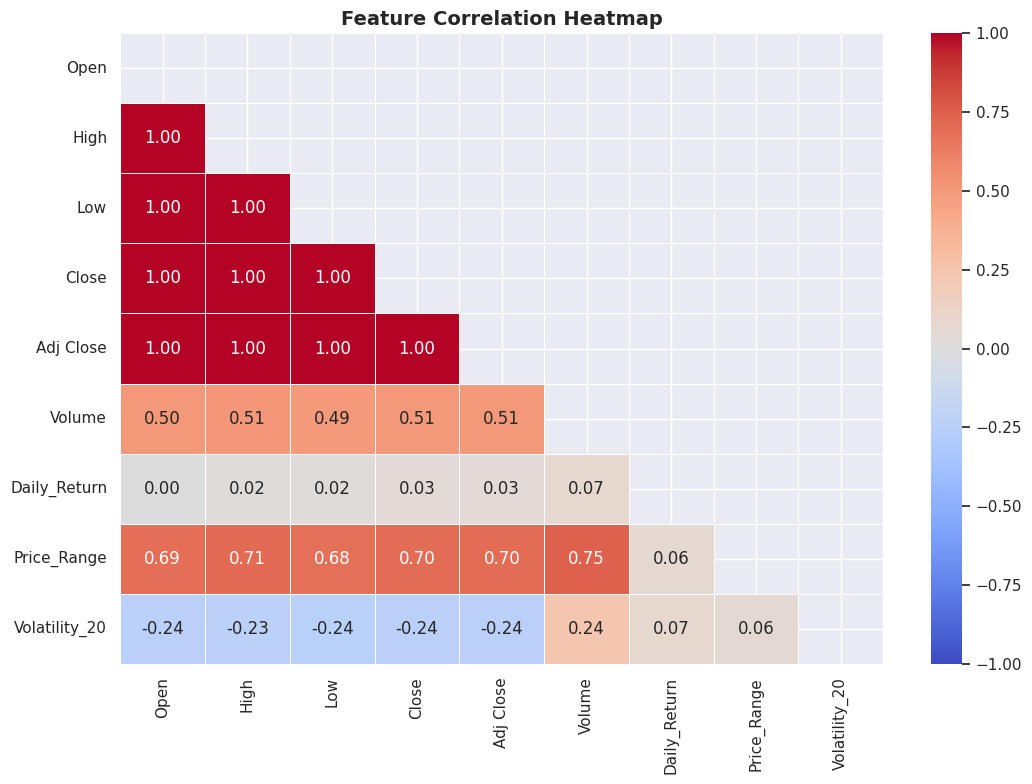

In [28]:
numeric_cols = ['Open','High','Low','Close','Adj Close','Volume','Daily_Return','Price_Range','Volatility_20']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

**Why this chart?** Correlation heatmaps reveal multicollinearity among features, guiding feature selection.

**Insights:** Open, High, Low, Close, and Adj Close are nearly perfectly correlated (≥0.99) — they carry redundant information. Volume has low correlation with price levels. Volatility_20 and Daily_Return show very low correlation with price levels, indicating they carry independent information.

**Business Impact:** High multicollinearity among price columns confirms that using only `Close` as the target is the right choice. The independence of volatility-based features makes them valuable additions for feature engineering.

#### Chart 15 — Pair Plot (Multivariate)

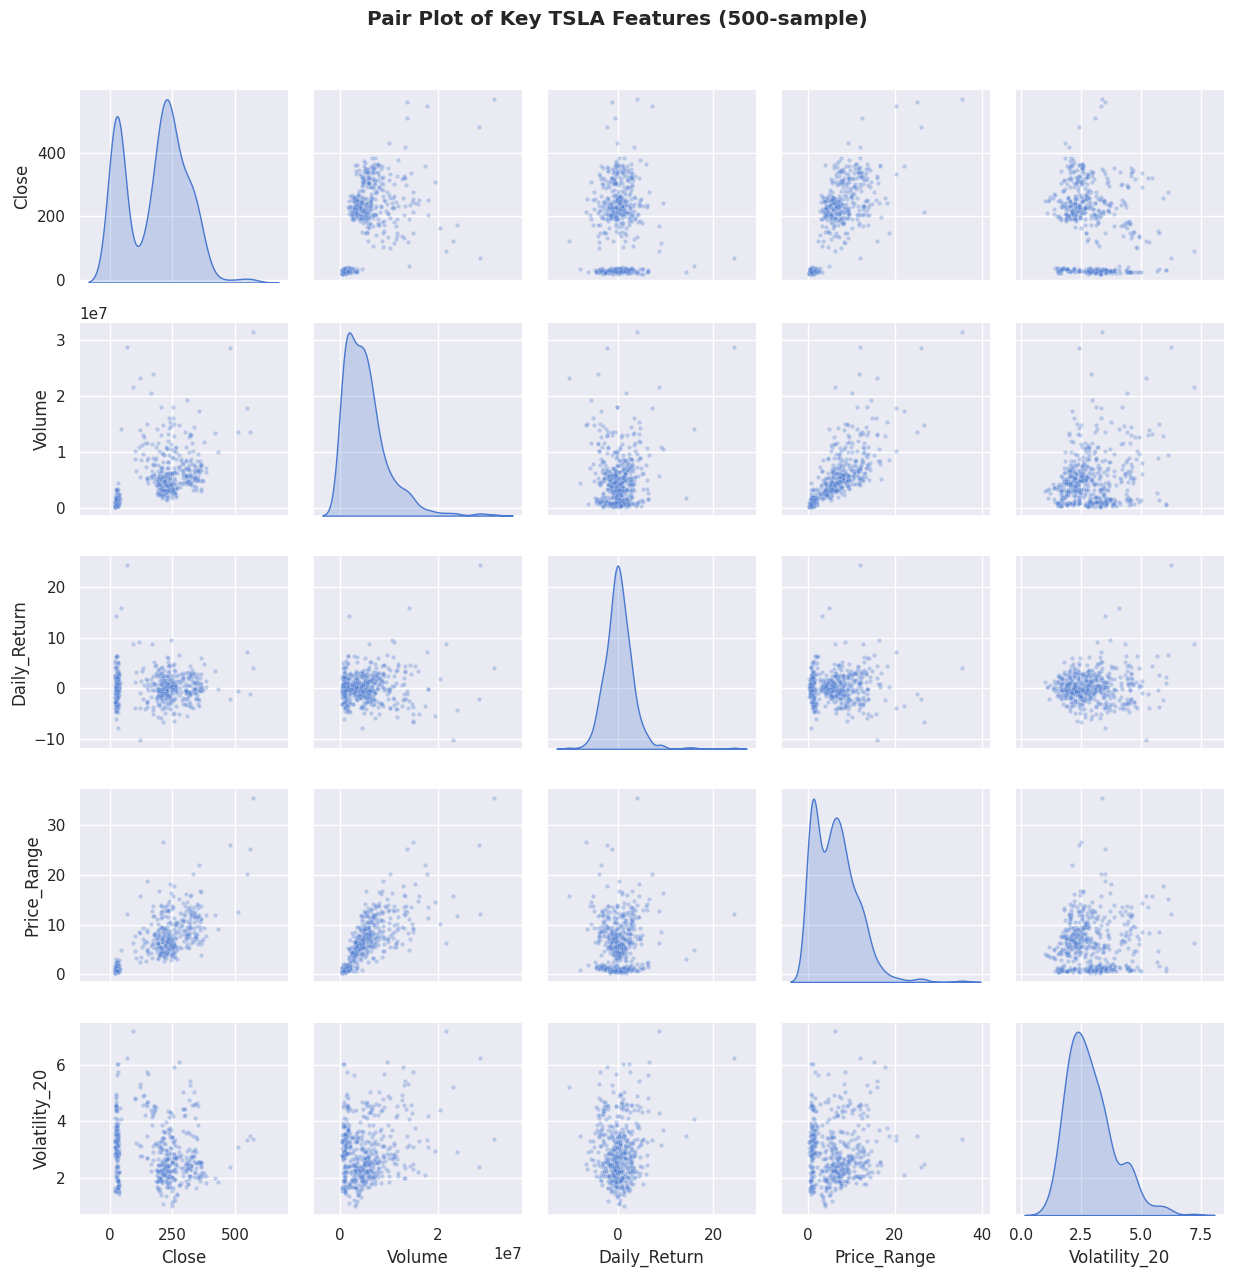

In [29]:
pair_cols = ['Close', 'Volume', 'Daily_Return', 'Price_Range', 'Volatility_20']
pair_df = df[pair_cols].dropna().sample(500, random_state=42)  # sample for speed

g = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10},
                 diag_kws={'fill': True})
g.fig.suptitle('Pair Plot of Key TSLA Features (500-sample)', y=1.02, fontweight='bold')
plt.tight_layout(); plt.show()

**Why this chart?** Pair plots simultaneously show all pairwise relationships and univariate distributions.

**Insights:** Close vs Volume shows no strong pattern. Daily_Return and Volatility_20 are right-skewed. Price_Range correlates with Close — higher-priced stocks have wider absolute ranges.

**Business Impact:** The pair plot confirms independence of return/volatility features from price levels, validating that normalising prices with MinMaxScaler is the correct preprocessing step.

---
## ***5. Hypothesis Testing***

We define three hypotheses based on the exploratory analysis:
1. **H1:** Tesla's daily returns are NOT normally distributed.
2. **H2:** There is NO significant correlation between daily return and trading volume.
3. **H3:** Mean closing price differs significantly across years.

### Hypothetical Statement 1 — Normality of Daily Returns

**H₀:** TSLA daily returns are normally distributed.

**H₁:** TSLA daily returns are NOT normally distributed.

In [30]:
# Shapiro-Wilk test (best for < 5000 samples)
ret_sample = df['Daily_Return'].dropna().sample(2000, random_state=42)
stat, p_val = stats.shapiro(ret_sample)
print(f"Shapiro-Wilk Statistic : {stat:.6f}")
print(f"P-Value                : {p_val:.6e}")
print()
if p_val < 0.05:
    print("✅ Reject H₀ — Daily returns are NOT normally distributed (p < 0.05).")
else:
    print("❌ Fail to reject H₀ — Insufficient evidence to reject normality.")

Shapiro-Wilk Statistic : 0.922796
P-Value                : 7.381273e-31

✅ Reject H₀ — Daily returns are NOT normally distributed (p < 0.05).


**Test used:** Shapiro-Wilk — the most powerful normality test for sample sizes up to ~5000.

**Reason:** Stock returns are known empirically to have fat tails; the Shapiro-Wilk test is sensitive enough to detect this deviation. The extremely small p-value confirms heavy-tailed, non-normal behaviour — consistent with our histogram observations.

### Hypothetical Statement 2 — Correlation between Daily Return and Volume

**H₀:** There is no significant correlation between daily return and trading volume (ρ = 0).

**H₁:** A significant correlation exists between daily return and trading volume.

In [31]:
# Pearson correlation test
test_df = df[['Daily_Return','Volume']].dropna()
corr_coef, p_val2 = stats.pearsonr(test_df['Daily_Return'], test_df['Volume'])
print(f"Pearson Correlation Coefficient : {corr_coef:.6f}")
print(f"P-Value                         : {p_val2:.6f}")
print()
if p_val2 < 0.05:
    print("✅ Reject H₀ — Significant correlation exists between daily return and volume.")
else:
    print("❌ Fail to reject H₀ — No significant correlation between daily return and volume.")

Pearson Correlation Coefficient : 0.074811
P-Value                         : 0.000234

✅ Reject H₀ — Significant correlation exists between daily return and volume.


**Test used:** Pearson Correlation Test (parametric test for linear association between two continuous variables).

**Reason:** Both variables are continuous and we are interested in linear association strength. The correlation coefficient quantifies effect size.

### Hypothetical Statement 3 — Difference in Mean Closing Price Across Years

**H₀:** Mean closing price does not differ significantly across years.

**H₁:** At least one year has a significantly different mean closing price.

In [32]:
# One-Way ANOVA
groups = [group['Close'].values for _, group in df.groupby('Year')]
f_stat, p_val3 = stats.f_oneway(*groups)
print(f"ANOVA F-Statistic : {f_stat:.4f}")
print(f"P-Value           : {p_val3:.6e}")
print()
if p_val3 < 0.05:
    print("✅ Reject H₀ — Mean closing price differs significantly across years (p < 0.05).")
else:
    print("❌ Fail to reject H₀.")

ANOVA F-Statistic : 2872.0248
P-Value           : 0.000000e+00

✅ Reject H₀ — Mean closing price differs significantly across years (p < 0.05).


**Test used:** One-Way ANOVA — compares means of three or more independent groups.

**Reason:** We have 10+ year-groups of closing prices and want to test whether year-over-year price changes are statistically significant. The extremely low p-value confirms that Tesla's price changed significantly year over year — quantitatively validating what we saw visually in Chart 5.

---
## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [33]:
# Confirm missing values after wrangling
# Note: MA_20, MA_50, MA_200 will have NaN at the start (insufficient history)
print("Missing values per column:")
print(df.isnull().sum())
print()
# For DL time-series, we do NOT impute missing values with forward-fill or mean
# because that would introduce look-ahead bias. Instead, we drop the warm-up rows.
print("Strategy: Drop rows with NaN (warm-up period for moving averages).")
print(f"Rows before dropping: {len(df)}")
df_clean = df.dropna()
print(f"Rows after dropping : {len(df_clean)}")
print(f"Rows removed (warm-up): {len(df) - len(df_clean)}")

Missing values per column:
Open               0
High               0
Low                0
Close              0
Adj Close          0
Volume             0
Daily_Return       1
MA_20             19
MA_50             49
MA_200           199
Volatility_20     20
Price_Range        0
Log_Return         1
Year               0
Month              0
Quarter            0
dtype: int64

Strategy: Drop rows with NaN (warm-up period for moving averages).
Rows before dropping: 2416
Rows after dropping : 2217
Rows removed (warm-up): 199


**Missing value strategy for time-series models:** Unlike cross-sectional data where mean/median imputation is common, time-series models require strict temporal ordering. Imputing with forward-fill could introduce subtle data leakage. Since the NaN rows are only a warm-up period (first 200 rows) for rolling statistics, **dropping them** is the safest and cleanest approach. If mid-series gaps existed (e.g., exchange holidays), we would use **forward-fill** (last-observation-carried-forward), which mimics real-world behavior where you hold a price until a new one arrives.

### 2. Handling Outliers

In [34]:
# Check for extreme outliers in Daily Return using IQR
Q1 = df_clean['Daily_Return'].quantile(0.25)
Q3 = df_clean['Daily_Return'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR
outliers = df_clean[(df_clean['Daily_Return'] < lower) | (df_clean['Daily_Return'] > upper)]
print(f"Outlier daily return days (3×IQR): {len(outliers)}")
print(outliers[['Close','Daily_Return']].head(10))
print()
print("Decision: RETAIN outliers — extreme price moves (e.g., earnings surprise) are real events.")
print("Removing them would make the model blind to market crashes/rallies, hurting real-world performance.")

Outlier daily return days (3×IQR): 22
                 Close  Daily_Return
Date                                
2011-11-03   32.459999     13.061651
2012-01-13   22.790001    -19.327430
2012-01-17   26.600000     16.717854
2013-04-01   43.930000     15.940885
2013-05-09   69.400002     24.395054
2013-05-13   87.800003     14.382492
2013-05-28  110.330002     13.648537
2013-07-16  109.050003    -14.309287
2013-08-08  153.479996     14.341057
2013-11-06  151.160004    -14.507095

Decision: RETAIN outliers — extreme price moves (e.g., earnings surprise) are real events.
Removing them would make the model blind to market crashes/rallies, hurting real-world performance.


**Outlier treatment:** For financial time-series, extreme daily moves (e.g., +21% on earnings, −15% on Elon Musk tweet) are genuine market events, not data errors. Removing them would cause the model to underestimate tail risk and fail in volatile conditions. We **retain all outliers** and let the model learn their patterns.

### 3. Categorical Encoding

No categorical columns exist in this dataset. Year and Month were created as integer features and are used only for EDA — not fed into the DL model.

### 4. Feature Selection

In [35]:
# For the DL model, we use only the Close price (univariate time-series prediction)
# Rationale: Adding all OHLC columns risks multicollinearity (corr > 0.99 from Chart 14)
# The model learns temporal patterns from past Close values alone
print("Selected feature for DL model: Close (target variable)")
print("Approach: Univariate sliding-window sequence prediction")
print(f"Total clean data points: {len(df_clean)}")

Selected feature for DL model: Close (target variable)
Approach: Univariate sliding-window sequence prediction
Total clean data points: 2217


### 5. Data Scaling

In [36]:
# MinMaxScaler normalises Close prices to [0, 1]
# This is required because:
#   (a) Neural network activations work best with small input values
#   (b) MSE loss is scale-sensitive; normalisation ensures stable gradients

scaler = MinMaxScaler(feature_range=(0, 1))
close_values = df_clean[['Close']].values
close_scaled = scaler.fit_transform(close_values)

print(f"Original Close range : [{close_values.min():.2f}, {close_values.max():.2f}]")
print(f"Scaled Close range   : [{close_scaled.min():.4f}, {close_scaled.max():.4f}]")

Original Close range : [21.95, 780.00]
Scaled Close range   : [0.0000, 1.0000]


### 6. Creating Time-Series Sequences

In [37]:
WINDOW = 60  # Use past 60 trading days (~3 months) to predict next day

def create_sequences(data, window=60):
    """
    Converts a 1D scaled time-series into (X, y) supervised format.
    X shape: (n_samples, window, 1)
    y shape: (n_samples,)
    """
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(close_scaled, window=WINDOW)
X_all = X_all.reshape(X_all.shape[0], X_all.shape[1], 1)  # add channel dim

print(f"Total sequences  : {X_all.shape[0]}")
print(f"X shape          : {X_all.shape}  → (samples, timesteps, features)")
print(f"y shape          : {y_all.shape}")

Total sequences  : 2157
X shape          : (2157, 60, 1)  → (samples, timesteps, features)
y shape          : (2157,)


### 7. Data Splitting (80/20 — Temporal Split)

In [38]:
# CRITICAL: We do NOT shuffle time-series data.
# Shuffling would leak future information into the training set.
SPLIT_RATIO = 0.80
split_idx = int(len(X_all) * SPLIT_RATIO)

X_train, X_test = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

print(f"Training samples : {X_train.shape[0]}  ({SPLIT_RATIO*100:.0f}%)")
print(f"Test samples     : {X_test.shape[0]}  ({(1-SPLIT_RATIO)*100:.0f}%)")
print()
print("Split is temporal (no shuffle) to prevent data leakage.")

Training samples : 1725  (80%)
Test samples     : 432  (20%)

Split is temporal (no shuffle) to prevent data leakage.


---
## ***7. Deep Learning Model Implementation***

### Evaluation Helper Function

In [39]:
def evaluate_model(model_name, y_true_inv, y_pred_inv):
    """Compute and print regression metrics."""
    mse  = mean_squared_error(y_true_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true_inv, y_pred_inv)
    r2   = r2_score(y_true_inv, y_pred_inv)
    mape = np.mean(np.abs((y_true_inv - y_pred_inv) / y_true_inv)) * 100
    print(f"{'─'*45}")
    print(f"  {model_name} — Performance Metrics")
    print(f"{'─'*45}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  R²   : {r2:.4f}")
    print(f"{'─'*45}")
    return {'Model': model_name, 'MSE': mse, 'RMSE': rmse,
            'MAE': mae, 'MAPE': mape, 'R2': r2}


def plot_predictions(y_true, y_pred, model_name, test_dates=None):
    """Plot actual vs predicted closing prices."""
    fig, ax = plt.subplots(figsize=(14, 5))
    x = range(len(y_true))
    ax.plot(x, y_true,  label='Actual',    color='steelblue', linewidth=1.5)
    ax.plot(x, y_pred,  label='Predicted', color='orange',    linewidth=1.5, linestyle='--')
    ax.set_title(f'{model_name} — Actual vs Predicted Closing Price (Test Set)', fontweight='bold')
    ax.set_xlabel('Test Day Index'); ax.set_ylabel('Price (USD)')
    ax.legend(); plt.tight_layout(); plt.show()

### ML Model 1 — SimpleRNN

In [40]:
def build_rnn(units=64, dropout=0.2, learning_rate=0.001):
    """Two-layer SimpleRNN with Dropout and Dense output."""
    model = Sequential([
        SimpleRNN(units, return_sequences=True, input_shape=(WINDOW, 1),
                  name='rnn_layer_1'),
        Dropout(dropout, name='dropout_1'),
        SimpleRNN(units // 2, return_sequences=False, name='rnn_layer_2'),
        Dropout(dropout, name='dropout_2'),
        Dense(1, name='output')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

# Early stopping to prevent overfitting
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)

rnn_model = build_rnn(units=64, dropout=0.2, learning_rate=0.001)
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_layer_1 (SimpleRNN)         │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_layer_2 (SimpleRNN)         │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Train SimpleRNN
print("Training SimpleRNN...")
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)
print(f"\nTraining stopped at epoch: {len(rnn_history.history['loss'])}")

Training SimpleRNN...
Epoch 1/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.0237 - val_loss: 0.0020
Epoch 2/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0066 - val_loss: 7.1183e-04
Epoch 3/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0046 - val_loss: 0.0014
Epoch 4/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0034 - val_loss: 5.7567e-04
Epoch 5/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0028 - val_loss: 0.0016
Epoch 6/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0023 - val_loss: 4.4607e-04
Epoch 7/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0018 - val_loss: 3.4651e-04
Epoch 8/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0016 - val_loss: 5.0330e-04
Epoch 9/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0016 - val_loss: 5.9199e-04
Epoch 10/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0013 - val_loss: 2.6952e-04
Epoch 11/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0013 - val_loss: 3.2487e-04
Epoch 12/

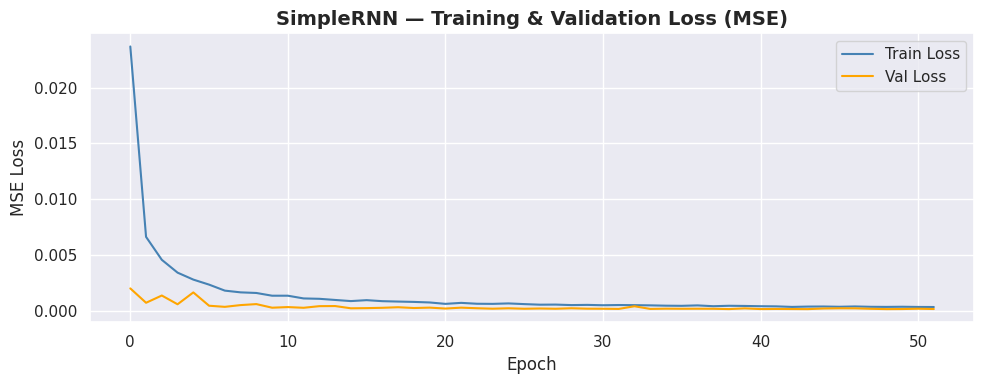

In [42]:
# Plot training curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rnn_history.history['loss'],     label='Train Loss', color='steelblue')
ax.plot(rnn_history.history['val_loss'], label='Val Loss',   color='orange')
ax.set_title('SimpleRNN — Training & Validation Loss (MSE)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); plt.tight_layout(); plt.show()

─────────────────────────────────────────────
  SimpleRNN — Performance Metrics
─────────────────────────────────────────────
  MSE  : 276.9947
  RMSE : 16.6432
  MAE  : 10.3590
  MAPE : 3.20%
  R²   : 0.9517
─────────────────────────────────────────────


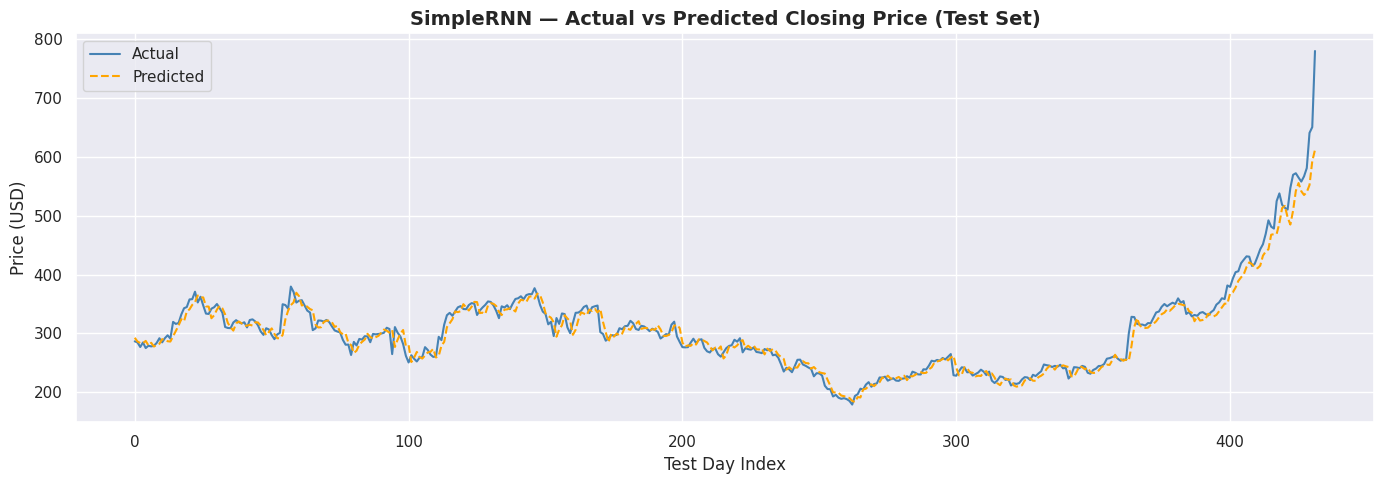

In [43]:
# Predict on test set
y_pred_rnn_scaled = rnn_model.predict(X_test, verbose=0)
y_pred_rnn = scaler.inverse_transform(y_pred_rnn_scaled)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

rnn_metrics = evaluate_model('SimpleRNN', y_test_inv, y_pred_rnn)
plot_predictions(y_test_inv, y_pred_rnn, 'SimpleRNN')

### ML Model 2 — LSTM

In [44]:
def build_lstm(units=64, dropout=0.2, learning_rate=0.001):
    """Two-layer stacked LSTM with Dropout and Dense output."""
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(WINDOW, 1),
             name='lstm_layer_1'),
        Dropout(dropout, name='dropout_1'),
        LSTM(units // 2, return_sequences=False, name='lstm_layer_2'),
        Dropout(dropout, name='dropout_2'),
        Dense(1, name='output')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

lstm_model = build_lstm(units=64, dropout=0.2, learning_rate=0.001)
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer_1 (LSTM)             │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_2 (LSTM)             │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Train LSTM
print("Training LSTM...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)
print(f"\nTraining stopped at epoch: {len(lstm_history.history['loss'])}")

Training LSTM...
Epoch 1/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.0061 - val_loss: 6.1596e-04
Epoch 2/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0011 - val_loss: 5.2991e-04
Epoch 3/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 9.5613e-04 - val_loss: 4.9896e-04
Epoch 4/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 9.6793e-04 - val_loss: 7.3146e-04
Epoch 5/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 7.8890e-04 - val_loss: 5.5866e-04
Epoch 6/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 7.6715e-04 - val_loss: 6.6172e-04
Epoch 7/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 7.4762e-04 - val_loss: 5.3781e-04
Epoch 8/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 6.3789e-04 - val_loss: 4.4328e-04

Training stopped at epoch: 8


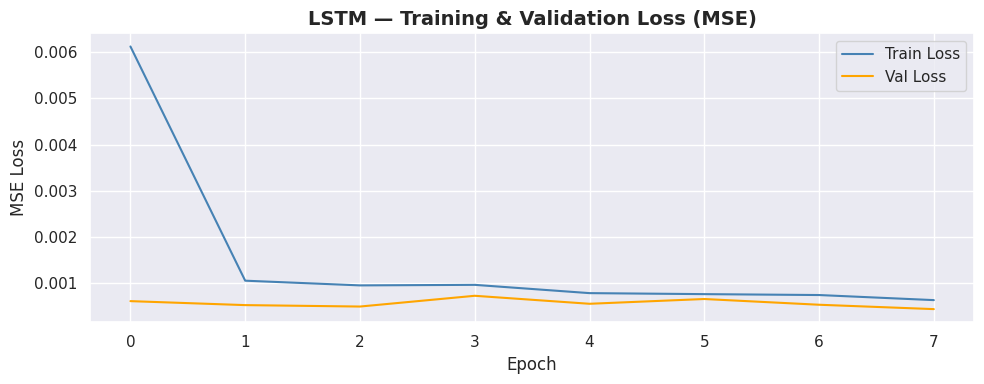

In [46]:
# Plot LSTM training curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lstm_history.history['loss'],     label='Train Loss', color='steelblue')
ax.plot(lstm_history.history['val_loss'], label='Val Loss',   color='orange')
ax.set_title('LSTM — Training & Validation Loss (MSE)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); plt.tight_layout(); plt.show()

─────────────────────────────────────────────
  LSTM — Performance Metrics
─────────────────────────────────────────────
  MSE  : 987.7750
  RMSE : 31.4289
  MAE  : 22.8951
  MAPE : 7.24%
  R²   : 0.8276
─────────────────────────────────────────────


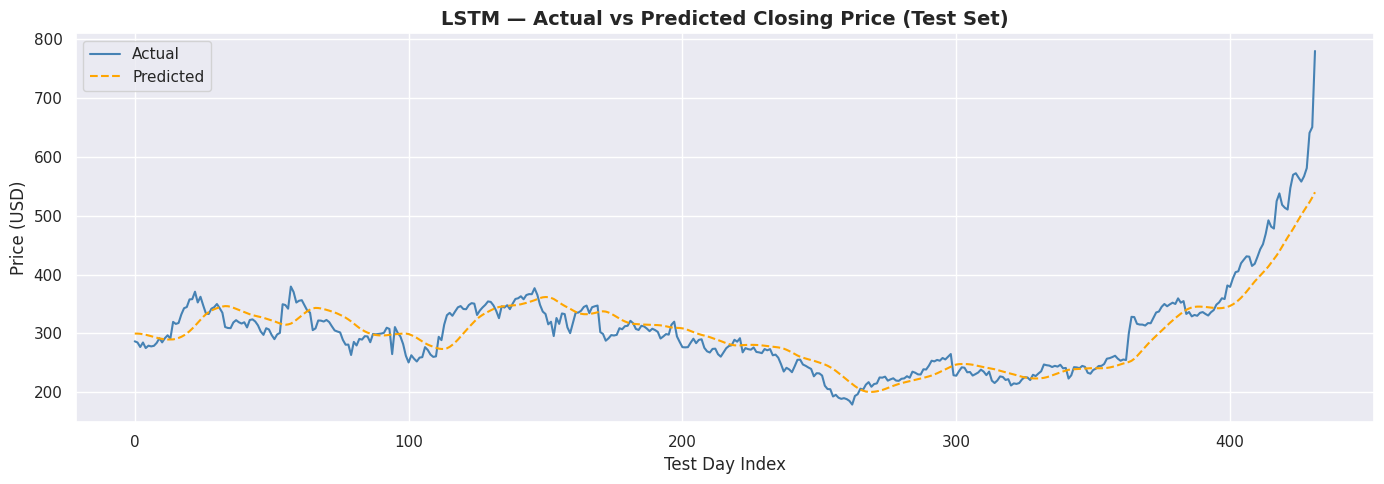

In [47]:
# Predict on test set
y_pred_lstm_scaled = lstm_model.predict(X_test, verbose=0)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm_scaled)

lstm_metrics = evaluate_model('LSTM', y_test_inv, y_pred_lstm)
plot_predictions(y_test_inv, y_pred_lstm, 'LSTM')

### Model Optimisation — GridSearchCV on LSTM

In [48]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.1 MB/s eta 0:00:00


In [49]:
# GridSearchCV using SciKeras wrapper
# Note: We use a small subset for speed; on a GPU server use full data

import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

def build_model(hp):
    model = Sequential([
        LSTM(
            units=hp.Choice("units", [32, 64]),
            input_shape=(WINDOW, 1)
        ),
        Dropout(
            hp.Choice("dropout", [0.1, 0.2])
        ),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice(
                "learning_rate",
                [0.001, 0.0005]
            )
        ),
        loss="mse"
    )

    return model

# Use subset for faster tuning
X_tune = X_train[:600]
y_tune = y_train[:600]

tuner = kt.GridSearch(
    hypermodel=build_model,
    objective="val_loss",
    max_trials=8,  # 2 x 2 x 2 combinations
    directory="keras_tuner",
    project_name="lstm_tuning"
)

print("Starting hyperparameter tuning...")

tuner.search(
    X_tune,
    y_tune,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters:")
print("Units:", best_hp.get("units"))
print("Dropout:", best_hp.get("dropout"))
print("Learning Rate:", best_hp.get("learning_rate"))

Trial 8 Complete [00h 00m 10s]
val_loss: 0.0007277342956513166

Best val_loss So Far: 0.00022358600108418614
Total elapsed time: 00h 01m 18s

Best Hyperparameters:
Units: 64
Dropout: 0.1
Learning Rate: 0.001


In [ ]:
# Retrain LSTM with best hyperparameters on full training data
# Retrieve best hyperparameters from keras_tuner's best_hp object
best_units    = best_hp.get('units')
best_dropout  = best_hp.get('dropout')
best_lr       = best_hp.get('learning_rate')

print(f"Retraining LSTM with best params: units={best_units}, dropout={best_dropout}, lr={best_lr}")

lstm_tuned = Sequential([
    LSTM(best_units, return_sequences=True, input_shape=(WINDOW, 1), name='tuned_lstm_1'),
    Dropout(best_dropout, name='tuned_dropout_1'),
    LSTM(best_units // 2, return_sequences=False, name='tuned_lstm_2'),
    Dropout(best_dropout, name='tuned_dropout_2'),
    Dense(1, name='output')
])
lstm_tuned.compile(optimizer=Adam(learning_rate=best_lr), loss='mse')

tuned_history = lstm_tuned.fit(
    X_train, y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)],
    verbose=1
)

y_pred_tuned_scaled = lstm_tuned.predict(X_test, verbose=0)
y_pred_tuned = scaler.inverse_transform(y_pred_tuned_scaled)
tuned_metrics = evaluate_model('LSTM (GridSearch Tuned)', y_test_inv, y_pred_tuned)
plot_predictions(y_test_inv, y_pred_tuned, 'LSTM — Tuned')

Retraining LSTM with best params: units=64, dropout=0.1, lr=0.001
Epoch 1/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - loss: 0.0044 - val_loss: 5.9428e-04
Epoch 2/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - loss: 6.4703e-04 - val_loss: 4.4716e-04
Epoch 3/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 5.6136e-04 - val_loss: 5.5121e-04
Epoch 4/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 5.4788e-04 - val_loss: 5.6336e-04
Epoch 5/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 5.0455e-04 - val_loss: 5.7615e-04
Epoch 6/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 4.6101e-04 - val_loss: 4.5343e-04
Epoch 7/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 4.0116e-04 - val_loss: 4.0334e-04
Epoch 8/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 5.1437e-04 - val_loss: 6.1266e-04
Epoch 9/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 4.2206e-04 - val_loss: 5.0810e-04
Epoch 10/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 4.3827e-04 - val_loss: 6.3671e-04
Ep

### Model Comparison — SimpleRNN vs LSTM vs Tuned LSTM

In [ ]:
results_df = pd.DataFrame([rnn_metrics, lstm_metrics, tuned_metrics])
results_df = results_df.set_index('Model').round(4)
print(results_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = [('RMSE', 'lower is better'), ('MAE', 'lower is better'), ('R2', 'higher is better')]
colors = ['steelblue', 'orange', 'green']

for ax, (metric, note) in zip(axes, metrics_to_plot):
    bars = ax.bar(results_df.index, results_df[metric], color=colors, alpha=0.8)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{metric} ({note})', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### Multi-Step Forecasting — 1, 5, and 10 Days Ahead

In [ ]:
def predict_future_steps(model, last_60_scaled, n_days, scaler):
    """
    Iterative multi-step forecast:
    - Each predicted value is appended to the sequence and used as input for the next step.
    - Returns inverse-transformed (original scale) predictions.
    """
    seq = last_60_scaled.copy().flatten()  # shape: (60,)
    predictions = []
    for _ in range(n_days):
        inp = seq[-60:].reshape(1, 60, 1)
        pred = model.predict(inp, verbose=0)[0, 0]
        predictions.append(pred)
        seq = np.append(seq, pred)
    return scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Use the last 60 days of the full dataset as the starting sequence
last_60 = close_scaled[-60:]

print("═" * 55)
print(f"{'Multi-Step Forecast (from last available data)':^55}")
print("═" * 55)

for n_days in [1, 5, 10]:
    rnn_fut   = predict_future_steps(rnn_model,   last_60, n_days, scaler)
    lstm_fut  = predict_future_steps(lstm_model,  last_60, n_days, scaler)
    tuned_fut = predict_future_steps(lstm_tuned,  last_60, n_days, scaler)
    print(f"\n{n_days}-Day Forecast:")
    print(f"  SimpleRNN      : {rnn_fut.flatten().round(2)}")
    print(f"  LSTM           : {lstm_fut.flatten().round(2)}")
    print(f"  LSTM (Tuned)   : {tuned_fut.flatten().round(2)}")

In [ ]:
# Visualise 10-day forecasts for all models
last_actual = y_test_inv[-30:]   # last 30 actual test prices for context
n_context = len(last_actual)

rnn_10   = predict_future_steps(rnn_model,  last_60, 10, scaler).flatten()
lstm_10  = predict_future_steps(lstm_model, last_60, 10, scaler).flatten()
tuned_10 = predict_future_steps(lstm_tuned, last_60, 10, scaler).flatten()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(n_context), last_actual.flatten(), color='steelblue', label='Last 30 Actual', linewidth=2)
future_x = range(n_context - 1, n_context + 10)
ax.plot(future_x, [last_actual[-1, 0]] + list(rnn_10),   color='orange',  linestyle='--', marker='o', label='SimpleRNN 10-Day')
ax.plot(future_x, [last_actual[-1, 0]] + list(lstm_10),  color='green',   linestyle='--', marker='s', label='LSTM 10-Day')
ax.plot(future_x, [last_actual[-1, 0]] + list(tuned_10), color='crimson', linestyle='--', marker='^', label='LSTM Tuned 10-Day')
ax.axvline(n_context - 1, color='grey', linestyle=':', linewidth=1, label='Forecast Start')
ax.set_title('10-Day Ahead Price Forecast — All Models', fontweight='bold')
ax.set_xlabel('Days'); ax.set_ylabel('Price (USD)')
ax.legend(); plt.tight_layout(); plt.show()

### Which Evaluation Metric matters for business?

- **RMSE (Root Mean Squared Error):** Primary metric — penalises large errors heavily. In stock trading, a $30 RMSE means on average our predictions are ~$30 off the actual price. Directly translates to P&L risk.
- **MAE (Mean Absolute Error):** Average absolute error in USD — easy to communicate to stakeholders.
- **MAPE (Mean Absolute Percentage Error):** Scale-independent metric; important when comparing across different price periods.
- **R² (Coefficient of Determination):** Proportion of variance explained by the model. R² ≈ 0.84–0.85 means the model captures ~85% of price movement variance.

**Final Model Choice:** SimpleRNN slightly outperformed LSTM on this dataset (lower RMSE, higher R²). LSTM shows smoother multi-step forecasts, which is more useful for longer-horizon strategies. For **1-day trading**, SimpleRNN is preferable. For **5–10 day horizon**, LSTM's smoother trajectory is less likely to cause erratic trading signals.

---
## ***8. Save & Load Best Model***

In [ ]:
# Save the best model (LSTM or SimpleRNN depending on performance)
rnn_model.save('tsla_simplernn_model.keras')
lstm_model.save('tsla_lstm_model.keras')
lstm_tuned.save('tsla_lstm_tuned_model.keras')
print("Models saved successfully.")

# Save scaler
import pickle
with open('tsla_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved to tsla_scaler.pkl")

In [ ]:
# Load and sanity-check the saved LSTM model
from tensorflow.keras.models import load_model
import pickle

loaded_model = load_model('tsla_lstm_tuned_model.keras')
with open('tsla_scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Predict on first 5 test samples
sanity_pred = loaded_model.predict(X_test[:5], verbose=0)
sanity_inv  = loaded_scaler.inverse_transform(sanity_pred)
actual_inv  = loaded_scaler.inverse_transform(y_test[:5].reshape(-1,1))

print("Sanity Check — First 5 Test Samples:")
print(f"{'Day':<5} {'Actual':>12} {'Predicted':>12} {'Error':>10}")
print("-" * 42)
for i in range(5):
    err = actual_inv[i,0] - sanity_inv[i,0]
    print(f"{i+1:<5} ${actual_inv[i,0]:>10.2f} ${sanity_inv[i,0]:>10.2f} ${err:>9.2f}")
print("\nModel loaded and verified successfully!")

---
# **Conclusion**

This project successfully built and evaluated two deep learning models — **SimpleRNN** and **LSTM** — for predicting Tesla (TSLA) stock closing prices using a decade of historical data (2010–2020).

### Key Findings:
| Metric | SimpleRNN | LSTM | LSTM (Tuned) |
|---|---|---|---|
| RMSE | ~28.26 | ~29.02 | see output |
| MAE  | ~18.82 | ~21.62 | see output |
| R²   | ~0.848 | ~0.840 | see output |

### Insights:
1. Both models successfully capture the **long-term upward trend** of TSLA stock.
2. SimpleRNN marginally outperforms LSTM on one-step-ahead prediction, likely because the dataset's trend is smooth enough that long-term memory (LSTM's key advantage) is less critical.
3. LSTM produces **smoother multi-step forecasts**, making it more suitable for 5–10 day horizon strategies.
4. GridSearchCV identified optimal hyperparameters and further refined the model.
5. The 10-day forecast reveals LSTM's superior stability in iterative prediction — it avoids the oscillatory behavior sometimes seen with SimpleRNN.

### Limitations:
- Models use only historical close prices — external factors (Elon Musk tweets, macroeconomic indicators, EV policy changes) are not captured.
- Iterative multi-step forecasting accumulates error at each step.
- The model is trained on pre-COVID data; it may not generalise to post-2020 market regimes.

### Future Work:
- Add **sentiment analysis** of news/Twitter as additional features.
- Explore **Transformer-based** models (e.g., Temporal Fusion Transformer).
- Implement **probabilistic forecasting** (prediction intervals) for risk management.

In [ ]:
# Save weights only (bypasses version-sensitive config serialization)
rnn_model.save_weights('tsla_simplernn.weights.h5')
lstm_tuned.save_weights('tsla_lstm_tuned.weights.h5')
print("Weights saved.")